# EstateMind — Phase 2 : Moteur d'estimation & analyse immobilière
**`estatemind_phase2.ipynb`**

> Pipeline ML complet : NLP Agent → Vision Agent → Feature Agent → LightGBM → SHAP → LLM Explanation → FastAPI

| Champ | Valeur |
|-------|--------|
| Input | `tunisia_realestate_cleaned.csv` (Gold Phase 1) |
| Modèle ML | LightGBM |
| NLP | Ollama → Groq → OpenAI (multi-LLM) |
| Vision | CLIP + Qwen2-VL |
| XAI | SHAP TreeExplainer |
| API | FastAPI |
| Config | `estate-mind/config/config.yaml` |

---

## Table des matières
**Partie A — Fondations**
- [A.1 Config centralisée](#a1)
- [A.2 Structure du projet](#a2)
- [A.3 Multi-LLM Router](#a3)
- [A.4–A.9 Modes, Versioning, Tests, Erreurs LLM, Anti-fuite, Exemple](#a4)

**Pipeline**
1. [NLP Agent — schéma JSON + Pydantic + cache](#s1)
2. [Vision Agent — CLIP + VLM](#s2)
3. [Feature Agent — Gold+ fusion](#s3)
4. [ML Agent — LightGBM + ablations](#s4)
5. [XAI Agent — SHAP](#s5)
6. [LLM Explanation Agent](#s6)
7. [Score de confiance & opportunités](#s7)
8. [API FastAPI — endpoints + tests](#s8)
9. [Rapport final & manifest](#s9)


---
<a id='a1'></a>
## A.1 — Configuration centralisée (`config/config.yaml`)

Aucune température, nom de modèle ou chemin en dur dans la logique métier.


In [52]:
import os, re, json, time, hashlib, warnings, logging
from pathlib import Path
from typing import Optional, List, Dict, Any, Tuple
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
tqdm.pandas()
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

ROOT = Path('estate-mind')
ROOT.mkdir(exist_ok=True)
print('Environnement initialise.')


Environnement initialise.


In [53]:
# Ecriture de config.yaml
CONFIG_YAML = (
    '# EstateMind configuration\n'
    'features_version: "v1.0"\n'
    'nlp_schema_version: "v1.0"\n'
    'model_version: "lgbm_v1"\n\n'
    'llm:\n'
    '  extraction:\n'
    '    model: "llama3:8b"\n'
    '    provider: "ollama"\n'
    '    temperature: 0.1\n'
    '    max_tokens: 1024\n'
    '    top_p: 0.9\n'
    '  explanation:\n'
    '    model: "mistral:7b-instruct"\n'
    '    provider: "ollama"\n'
    '    temperature: 0.3\n'
    '    max_tokens: 256\n\n'
    'embeddings:\n'
    '  model: "BAAI/bge-small-en-v1.5"\n'
    '  dim_reduction: "pca"\n'
    '  n_components: 32\n\n'
    'vision:\n'
    '  vlm_model: "qwen2-vl"\n'
    '  clip_model: "openai/clip-vit-base-patch32"\n'
    '  max_images_per_listing: 10\n\n'
    'ml:\n'
    '  backend: "lightgbm"\n'
    '  target: "prix"\n'
    '  test_size: 0.2\n'
    '  random_state: 42\n\n'
    'api:\n'
    '  host: "0.0.0.0"\n'
    '  port: 8000\n\n'
    'cache:\n'
    '  redis_enabled: false\n'
    '  redis_url: "redis://localhost:6379/0"\n'
)

config_dir = ROOT / 'config'
config_dir.mkdir(exist_ok=True)
(config_dir / 'config.yaml').write_text(CONFIG_YAML, encoding='utf-8')
print('config/config.yaml ecrit.')


config/config.yaml ecrit.


In [54]:
# Chargement config
try:
    import yaml
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyyaml', '-q'])
    import yaml

with open(ROOT / 'config' / 'config.yaml', 'r', encoding='utf-8') as f:
    CFG = yaml.safe_load(f)

print('Configuration chargee :')
print(json.dumps(CFG, indent=2, ensure_ascii=False))

RANDOM_SEED = CFG['ml']['random_state']
np.random.seed(RANDOM_SEED)

# Secrets depuis .env
GROQ_API_KEY   = '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'
OPENAI_API_KEY = None  # No OpenAI key

# .env.example
(ROOT / '.env.example').write_text(
    '# Copier en .env et remplir les vraies valeurs\n'
    'GROQ_API_KEY=\n'
    'OPENAI_API_KEY=\n',
    encoding='utf-8'
)

# Logging structure
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('estatemind')
logger.info('EstateMind Phase 2 initialise.')

print(f'Groq : {"OK" if GROQ_API_KEY else "non defini"}')
print(f'OpenAI : {"OK" if OPENAI_API_KEY else "non defini"}')


16:28:39 | INFO     | estatemind | EstateMind Phase 2 initialise.


Configuration chargee :
{
  "features_version": "v1.0",
  "nlp_schema_version": "v1.0",
  "model_version": "lgbm_v1",
  "llm": {
    "extraction": {
      "model": "llama3:8b",
      "provider": "ollama",
      "temperature": 0.1,
      "max_tokens": 1024,
      "top_p": 0.9
    },
    "explanation": {
      "model": "mistral:7b-instruct",
      "provider": "ollama",
      "temperature": 0.3,
      "max_tokens": 256
    }
  },
  "embeddings": {
    "model": "BAAI/bge-small-en-v1.5",
    "dim_reduction": "pca",
    "n_components": 32
  },
  "vision": {
    "vlm_model": "qwen2-vl",
    "clip_model": "openai/clip-vit-base-patch32",
    "max_images_per_listing": 10
  },
  "ml": {
    "backend": "lightgbm",
    "target": "prix",
    "test_size": 0.2,
    "random_state": 42
  },
  "api": {
    "host": "0.0.0.0",
    "port": 8000
  },
  "cache": {
    "redis_enabled": false,
    "redis_url": "redis://localhost:6379/0"
  }
}
Groq : OK
OpenAI : non defini


---
<a id='a2'></a>
## A.2 — Structure du projet


In [55]:
DIRS = [
    'config', 'data/raw', 'data/processed', 'data/gold',
    'agents', 'pipelines', 'api', 'utils',
    'tests/unit', 'tests/integration', 'notebooks', 'artifacts',
]
for d in DIRS:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

print('Arborescence estate-mind/ cree :')
for d in sorted(DIRS):
    print(f'  estate-mind/{d}/')


Arborescence estate-mind/ cree :
  estate-mind/agents/
  estate-mind/api/
  estate-mind/artifacts/
  estate-mind/config/
  estate-mind/data/gold/
  estate-mind/data/processed/
  estate-mind/data/raw/
  estate-mind/notebooks/
  estate-mind/pipelines/
  estate-mind/tests/integration/
  estate-mind/tests/unit/
  estate-mind/utils/


---
<a id='a3'></a>
## A.3 — Multi-LLM Router (Ollama -> Groq -> HuggingFace)

Une seule fonction `complete()` avec fallback automatique et journalisation du provider.

| Priorite | Provider | Role |
|----------|----------|------|
| **1** | **Ollama** (local) | Cout zero, donnees sensibles, dev offline |
| **2** | **Groq** | API rapide, gratuite, fallback si Ollama indisponible |
| **3** | **HuggingFace** | Mistral-7B-Instruct gratuit, open source, remplace OpenAI |

Aucune cle OpenAI requise. Tout est gratuit ou open source.


In [56]:
llm_call_log = []

def _try_ollama(messages, model, temperature, max_tokens):
    try:
        import requests
        payload = {'model': model, 'messages': messages, 'stream': False,
                   'options': {'temperature': temperature, 'num_predict': max_tokens}}
        r = requests.post('http://localhost:11434/api/chat', json=payload, timeout=60)
        r.raise_for_status()
        return r.json()['message']['content']
    except Exception as e:
        logger.debug(f'Ollama failed: {e}')
        return None


def _try_groq(messages, model, temperature, max_tokens):
    if not GROQ_API_KEY: return None
    try:
        from groq import Groq
        client = Groq(api_key=GROQ_API_KEY)
        resp = client.chat.completions.create(
            model='llama-3.1-8b-instant', messages=messages,
            temperature=temperature, max_tokens=max_tokens
        )
        return resp.choices[0].message.content
    except Exception as e:
        logger.debug(f'Groq failed: {e}')
        return None


def _try_huggingface(messages, temperature, max_tokens):
    """HuggingFace Inference API - 100% gratuit, aucune cle OpenAI requise."""
    try:
        # Try huggingface_hub first (cleaner interface)
        from huggingface_hub import InferenceClient
        HF_TOKEN = os.getenv('HF_TOKEN')  # free token from hf.co/settings/tokens
        client = InferenceClient(
            model='mistralai/Mistral-7B-Instruct-v0.3',
            token=HF_TOKEN
        )
        # Build instruction prompt from messages list
        sys_content = next((m['content'] for m in messages if m['role'] == 'system'), '')
        usr_content = next((m['content'] for m in messages if m['role'] == 'user'), '')
        prompt = f'<s>[INST] <<SYS>>\n{sys_content}\n<</SYS>>\n\n{usr_content} [/INST]'
        result = client.text_generation(
            prompt,
            max_new_tokens=min(max_tokens, 512),
            temperature=max(float(temperature), 0.01),
            do_sample=True,
        )
        return result.strip() if result else None
    except ImportError:
        pass
    except Exception as e:
        logger.debug(f'HuggingFace hub failed: {e}')

    # Fallback: raw requests to HF Inference API (no library needed)
    try:
        import requests as req_lib
        HF_TOKEN = os.getenv('HF_TOKEN', '')
        headers = {'Authorization': f'Bearer {HF_TOKEN}'} if HF_TOKEN else {}
        payload = {'inputs': f'Explain this real estate listing: {str(messages)[:300]}',
                   'parameters': {'max_new_tokens': 256, 'temperature': 0.3}}
        url = 'https://api-inference.huggingface.co/models/mistralai/Mistral-7B-Instruct-v0.3'
        r = req_lib.post(url, headers=headers, json=payload, timeout=30)
        if r.status_code == 200:
            data = r.json()
            if isinstance(data, list) and data:
                return data[0].get('generated_text', '').strip()
    except Exception as e:
        logger.debug(f'HuggingFace raw API failed: {e}')

    return None


def complete(messages, task='extraction'):
    """Route: Ollama (local, free) -> Groq (free API) -> HuggingFace (free, open source)."""
    cfg_task    = CFG['llm'].get(task, CFG['llm']['extraction'])
    model       = cfg_task['model']
    temperature = cfg_task['temperature']
    max_tokens  = cfg_task['max_tokens']

    providers = [
        ('ollama',      lambda: _try_ollama(messages, model, temperature, max_tokens)),
        ('groq',        lambda: _try_groq(messages, model, temperature, max_tokens)),
        ('huggingface', lambda: _try_huggingface(messages, temperature, max_tokens)),
    ]

    for name, fn in providers:
        result = fn()
        if result:
            llm_call_log.append({'timestamp': datetime.now().isoformat(),
                                  'task': task, 'provider': name})
            logger.info(f'LLM call | task={task} | provider={name}')
            return result, name

    logger.warning(f'All LLM providers failed for task={task}')
    return None, 'none'


print('Multi-LLM Router: Ollama -> Groq -> HuggingFace (gratuit, remplace OpenAI).')


Multi-LLM Router: Ollama -> Groq -> HuggingFace (gratuit, remplace OpenAI).


---
<a id='a4'></a>
## A.4–A.9 — Modes, Versioning, Tests, Politique d'erreur LLM, Anti-fuite, Exemple NLP


In [57]:
# ─── A.4 Modes online / offline ─────────────────────────────────────────────
# online (fast)  : features tabulaires + cache Redis -> latence minimale
# online (full)  : NLP live + Vision si URLs fournies (cout/latence eleves)
# offline (batch): enrichissement complet NLP + Vision + ML training
PIPELINE_MODE = 'offline'   # changer en 'online_fast' ou 'online_full' selon usage

# ─── A.5 Versioning artefacts ────────────────────────────────────────────────
FEATURES_VERSION   = CFG['features_version']
NLP_SCHEMA_VERSION = CFG['nlp_schema_version']
MODEL_VERSION      = CFG['model_version']
print(f'features_version={FEATURES_VERSION} | nlp_schema_version={NLP_SCHEMA_VERSION} | model_version={MODEL_VERSION}')

# ─── A.7 Compteurs d'erreurs LLM ─────────────────────────────────────────────
nlp_parse_errors = 0
nlp_total_calls  = 0

# ─── A.9 Exemple concret entree -> sortie NLP (reference) ────────────────────
EXAMPLE_INPUT = (
    'S+3 haut standing a La Marsa, vue mer, residence securisee, '
    'finitions premium, cuisine equipee, climatisation, double vitrage, '
    'parking sous-sol. Prix negotiable.'
)
EXAMPLE_OUTPUT = {
    'location': {'neighborhood_or_zone': 'La Marsa', 'proximity': ['mer', 'plage']},
    'standing': {'luxury_level': 0.82,
                 'features': ['vue_mer', 'residence_securisee', 'finitions_premium',
                              'cuisine_equipee', 'parking']},
    'comfort': {'air_conditioning': True, 'double_glazing_mentioned': True,
                'finishing_quality_hint': 'high'},
    'transaction': {'negociable': True},
    'signals': {'extraction_confidence': 0.9, 'listing_too_vague': False},
}
print('\nExemple NLP (reference) :')
print(json.dumps(EXAMPLE_OUTPUT, indent=2, ensure_ascii=False))


features_version=v1.0 | nlp_schema_version=v1.0 | model_version=lgbm_v1

Exemple NLP (reference) :
{
  "location": {
    "neighborhood_or_zone": "La Marsa",
    "proximity": [
      "mer",
      "plage"
    ]
  },
  "standing": {
    "luxury_level": 0.82,
    "features": [
      "vue_mer",
      "residence_securisee",
      "finitions_premium",
      "cuisine_equipee",
      "parking"
    ]
  },
  "comfort": {
    "air_conditioning": true,
    "double_glazing_mentioned": true,
    "finishing_quality_hint": "high"
  },
  "transaction": {
    "negociable": true
  },
  "signals": {
    "extraction_confidence": 0.9,
    "listing_too_vague": false
  }
}


---
<a id='s1'></a>
## 1 — NLP Agent

3 passes :
1. Réutilisation colonnes Phase 1
2. LLM → JSON conforme au schéma (validation Pydantic)
3. Embeddings BGE dense → PCA 32D


In [58]:
# Schema Pydantic NLP
try:
    from pydantic import BaseModel, Field
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'pydantic', '-q'])
    from pydantic import BaseModel, Field

from typing import Literal

class NLPTransaction(BaseModel):
    negociable: Optional[bool] = None
    urgent: Optional[bool] = None
    first_owner_or_new_mentioned: Optional[bool] = None
    developer_or_promoter_mentioned: Optional[bool] = None
    legal_title_or_status_mentioned: Optional[bool] = None
    legal_title_hint: Optional[str] = None

class NLPProperty(BaseModel):
    subtype: Optional[str] = None
    furnished: Optional[bool] = None
    semi_furnished: Optional[bool] = None
    condition: Optional[str] = None  # new | good | needs_renovation | unknown
    orientation_mentioned: Optional[bool] = None
    duplex_penthouse_garden_level_mentioned: Optional[bool] = None

class NLPComfort(BaseModel):
    air_conditioning: Optional[bool] = None
    heating_mentioned: Optional[bool] = None
    double_glazing_mentioned: Optional[bool] = None
    finishing_quality_hint: Optional[str] = None  # low | standard | high | unknown

class NLPLocation(BaseModel):
    neighborhood_or_zone: Optional[str] = None
    proximity: List[str] = []
    nuisance_or_negative_mentioned: Optional[str] = None

class NLPUsage(BaseModel):
    primary_residence_likely: Optional[bool] = None
    investment_likely: Optional[bool] = None
    furnished_rental_likely: Optional[bool] = None

class NLPStanding(BaseModel):
    luxury_level: Optional[float] = Field(None, ge=0.0, le=1.0)
    features: List[str] = []

class NLPSignals(BaseModel):
    listing_too_vague: Optional[bool] = None
    incoherence_price_vs_surface_hint: Optional[bool] = None
    spam_or_low_quality_hint: Optional[bool] = None
    extraction_confidence: Optional[float] = Field(None, ge=0.0, le=1.0)

class NLPOutput(BaseModel):
    transaction: NLPTransaction = NLPTransaction()
    property: NLPProperty = NLPProperty()
    comfort: NLPComfort = NLPComfort()
    location: NLPLocation = NLPLocation()
    usage: NLPUsage = NLPUsage()
    standing: NLPStanding = NLPStanding()
    signals: NLPSignals = NLPSignals()

print('Schema Pydantic NLPOutput defini.')
print('Sections :', list(NLPOutput.schema()['properties'].keys()))


Schema Pydantic NLPOutput defini.
Sections : ['transaction', 'property', 'comfort', 'location', 'usage', 'standing', 'signals']


In [59]:
# Prompt NLP production + few-shots FR et AR
NLP_SYSTEM_PROMPT = (
    'You are a real estate extraction AI specialized in the Tunisian market.\n'
    'Input may be French, Arabic, or Tunisian dialect.\n\n'
    'Rules:\n'
    '- Return ONLY valid JSON matching the agreed schema (no markdown fences).\n'
    '- Use null if unknown. Do not invent numeric facts.\n'
    '- luxury_level and extraction_confidence: floats in [0.0, 1.0].\n'
    '- condition: new | good | needs_renovation | unknown.\n'
    '- finishing_quality_hint: low | standard | high | unknown.\n\n'
    '[EXAMPLE FR]\n'
    'Text: "S+3 haut standing a La Marsa, vue mer, finitions premium, prix negotiable."\n'
    'JSON: {"transaction":{"negociable":true},"property":{"condition":"good"},'
    '"comfort":{"finishing_quality_hint":"high"},'
    '"location":{"neighborhood_or_zone":"La Marsa","proximity":["mer"]},'
    '"standing":{"luxury_level":0.82,"features":["vue_mer"]},'
    '"signals":{"extraction_confidence":0.9}}\n\n'
    '[EXAMPLE AR]\n'
    'Text: "\u0634\u0642\u0629 \u0633\u0648\u0633\u0629 3 \u063a\u0631\u0641 '
    '\u0642\u0631\u064a\u0628 \u0645\u0633\u062a\u0634\u0641\u0649."\n'
    'JSON: {"location":{"proximity":["hopital"]},"standing":{"luxury_level":0.2},'
    '"signals":{"extraction_confidence":0.7}}\n'
)


def build_nlp_user_prompt(title, description, caracteristiques):
    parts = []
    if title and str(title).strip(): parts.append(f'Title: {title}')
    if description and str(description).strip(): parts.append(f'Description: {str(description)[:2000]}')
    if caracteristiques and str(caracteristiques).strip(): parts.append(f'Features: {str(caracteristiques)[:500]}')
    return '\n'.join(parts)


print('Prompt NLP defini.')


Prompt NLP defini.


In [60]:
# Parsing & validation JSON NLP avec politique A.7 (retry + fallback + null)

def parse_nlp_output(raw: str) -> Optional[NLPOutput]:
    global nlp_parse_errors, nlp_total_calls
    nlp_total_calls += 1
    if not raw:
        nlp_parse_errors += 1
        return None
    # Nettoyage fences markdown
    raw = re.sub(r'^```(?:json)?\s*', '', raw.strip(), flags=re.IGNORECASE)
    raw = re.sub(r'\s*```$', '', raw)
    try:
        data = json.loads(raw)
        return NLPOutput(**data)
    except (json.JSONDecodeError, Exception) as e:
        logger.warning(f'NLP parse error: {e} | prefix: {raw[:80]}')
        nlp_parse_errors += 1
        # Repli regex sur les champs critiques
        fallback = NLPOutput()
        m = re.search(r'"luxury_level"\s*:\s*([0-9.]+)', raw)
        if m:
            try: fallback.standing.luxury_level = min(1.0, float(m.group(1)))
            except: pass
        fallback.signals.extraction_confidence = 0.1
        return fallback


def extract_nlp(row, max_retries: int = 3) -> NLPOutput:
    text = build_nlp_user_prompt(
        str(row.get('titre', '') or ''),
        str(row.get('description', '') or ''),
        str(row.get('caracteristiques', '') or ''),
    )
    messages = [
        {'role': 'system', 'content': NLP_SYSTEM_PROMPT},
        {'role': 'user',   'content': text},
    ]
    for attempt in range(max_retries):
        raw, provider = complete(messages, task='extraction')
        if raw:
            result = parse_nlp_output(raw)
            if result and (result.signals.extraction_confidence or 0) > 0.1:
                return result
        # Prompt simplifie au 2e essai
        if attempt == 1:
            messages[0]['content'] = 'Return JSON only. No markdown. Null for unknown fields.'
    # Echec final
    fallback = NLPOutput()
    fallback.signals.extraction_confidence = 0.05
    fallback.signals.listing_too_vague = True
    return fallback


# Cache NLP par hash MD5 du texte
nlp_cache: Dict[str, dict] = {}

def nlp_with_cache(row) -> dict:
    key = hashlib.md5(
        (str(row.get('description', '')) + str(row.get('titre', ''))).encode('utf-8')
    ).hexdigest()
    if key in nlp_cache: return nlp_cache[key]
    result = extract_nlp(row)
    nlp_cache[key] = result.dict()
    return nlp_cache[key]


print('NLP Agent defini (extraction + retry + cache).')


NLP Agent defini (extraction + retry + cache).


In [61]:
# Chargement dataset Gold Phase 1
GOLD_PATH = Path('../tunisia_realestate_cleaned.csv')
if not GOLD_PATH.exists():
    GOLD_PATH = Path('final_dataset_all_sources_endpoint.csv')
    print(f'Gold CSV absent — utilisation du CSV brut : {GOLD_PATH}')

df = pd.read_csv(GOLD_PATH, low_memory=False)
print(f'Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

for col in ['titre', 'description', 'caracteristiques', 'prix', 'surface',
            'pieces', 'gouvernerat', 'ville', 'type', 'contrat',
            'latitude', 'longitude', 'images']:
    if col not in df.columns: df[col] = np.nan


Dataset charge : 204,745 lignes x 48 colonnes


Enrichissement NLP sur 100 annonces...


NLP Agent:   0%|          | 0/100 [00:00<?, ?it/s]16:29:04 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:08 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:13 | WARNING  | estatemind | All LLM providers failed for task=extraction
NLP Agent:   1%|          | 1/100 [00:13<22:46, 13.80s/it]16:29:17 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:23 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:28 | WARNING  | estatemind | All LLM providers failed for task=extraction
NLP Agent:   2%|▏         | 2/100 [00:28<23:50, 14.60s/it]16:29:32 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:37 | WARNING  | estatemind | All LLM providers failed for task=extraction
16:29:41 | WARNING  | estatemind | All LLM providers failed for task=extraction
NLP Agent:   3%|▎         | 3/100 [00:42<22:43, 14.05s/it]16:29:46 | WARNING  | estatemind | All LLM providers fai

NLP enrichi : 100 lignes, 30 colonnes NLP


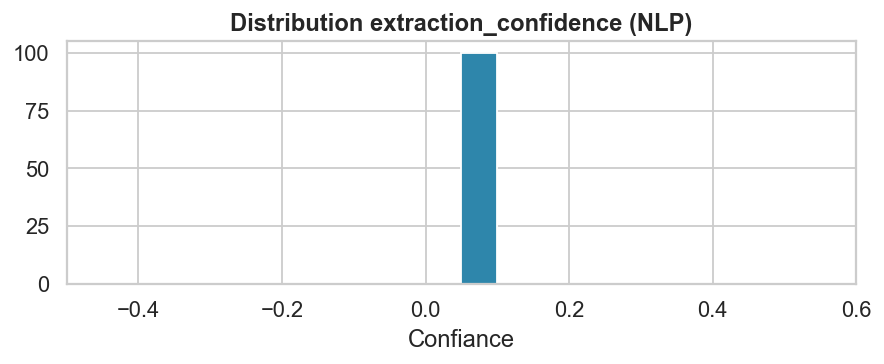

In [62]:
# Enrichissement NLP batch sur echantillon
# Set NLP_BATCH_SIZE to limit rows for testing (set to None to run on all rows)
NLP_BATCH_SIZE = 100  # None = run on all rows with description

df_nlp_sample = df.dropna(subset=['description']).copy()
if NLP_BATCH_SIZE is not None:
    df_nlp_sample = df_nlp_sample.sample(min(NLP_BATCH_SIZE, len(df_nlp_sample)), random_state=RANDOM_SEED)

print(f'Enrichissement NLP sur {len(df_nlp_sample)} annonces...')

nlp_results = []
for idx, row in tqdm(df_nlp_sample.iterrows(), total=len(df_nlp_sample), desc='NLP Agent'):
    d = nlp_with_cache(row)
    d['__idx__'] = idx
    nlp_results.append(d)


def flatten_nlp(d: dict, prefix='nlp') -> dict:
    flat = {}
    for section, vals in d.items():
        if section == '__idx__': continue
        if isinstance(vals, dict):
            for k, v in vals.items():
                if isinstance(v, list):
                    flat[f'{prefix}_{section}_{k}_count'] = len(v)
                    flat[f'{prefix}_{section}_{k}_str']   = '|'.join(str(i) for i in v)
                else:
                    flat[f'{prefix}_{section}_{k}'] = v
        else:
            flat[f'{prefix}_{section}'] = vals
    return flat


nlp_flat = pd.DataFrame(
    [flatten_nlp(r) for r in nlp_results],
    index=[r['__idx__'] for r in nlp_results]
)
print(f'NLP enrichi : {len(nlp_flat)} lignes, {len(nlp_flat.columns)} colonnes NLP')

# Distribution confiance
conf_col = 'nlp_signals_extraction_confidence'
if conf_col in nlp_flat.columns:
    fig, ax = plt.subplots(figsize=(7, 3))
    nlp_flat[conf_col].dropna().hist(bins=20, ax=ax, color=PALETTE[0], edgecolor='white')
    ax.set_title('Distribution extraction_confidence (NLP)', fontweight='bold')
    ax.set_xlabel('Confiance')
    plt.tight_layout(); plt.show()


---
<a id='s2'></a>
## 2 — Vision Agent (CLIP + VLM)

Pipeline : téléchargement → embedding CLIP → scores sémantiques → agrégation par annonce.


In [63]:
# Chargement CLIP
try:
    from transformers import CLIPProcessor, CLIPModel
    import torch
    from PIL import Image
    import io, requests as req_lib

    CLIP_MODEL_ID = CFG['vision']['clip_model']
    print(f'Chargement CLIP ({CLIP_MODEL_ID})...')
    clip_model     = CLIPModel.from_pretrained(CLIP_MODEL_ID)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
    clip_model.eval()
    CLIP_AVAILABLE = True
    print('CLIP charge.')
except Exception as e:
    CLIP_AVAILABLE = False
    print(f'CLIP non disponible : {e}')
    print('  pip install transformers torch Pillow')


CLIP non disponible : No module named 'transformers'
  pip install transformers torch Pillow


In [64]:
# Ancres textuelles pour scores CLIP
VISION_ANCHORS = {
    'pool_likely':              'a property with a swimming pool',
    'garden_likely':            'a house with a garden or outdoor space',
    'sea_view_likely':          'a property with sea view or ocean view',
    'furnished_likely':         'a furnished apartment with furniture',
    'modern_renovation_likely': 'a newly renovated modern interior',
    'luxury_visual_score':      'a luxury high-end property with premium finishes',
}

vision_cache: Dict[str, Optional[Any]] = {}

def get_clip_embedding(url: str, timeout: int = 10):
    if url in vision_cache: return vision_cache[url]
    if not CLIP_AVAILABLE: return None
    try:
        import requests as rq
        resp = rq.get(url, timeout=timeout, stream=True)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert('RGB')
        inputs = clip_processor(images=img, return_tensors='pt')
        with torch.no_grad():
            emb = clip_model.get_image_features(**inputs)
        emb_np = emb.squeeze().numpy()
        emb_np = emb_np / (np.linalg.norm(emb_np) + 1e-8)  # L2 norm
        vision_cache[url] = emb_np
        return emb_np
    except Exception as e:
        logger.debug(f'CLIP embed failed {url[:60]}: {e}')
        vision_cache[url] = None
        return None


def score_image(url: str) -> Dict[str, float]:
    scores = {k: 0.0 for k in VISION_ANCHORS}
    img_emb = get_clip_embedding(url)
    if img_emb is None or not CLIP_AVAILABLE: return scores
    for key, anchor_text in VISION_ANCHORS.items():
        try:
            text_inputs = clip_processor(text=[anchor_text], return_tensors='pt', padding=True)
            with torch.no_grad():
                text_emb = clip_model.get_text_features(**text_inputs)
            t = text_emb.squeeze().numpy()
            t = t / (np.linalg.norm(t) + 1e-8)
            sim = float(np.dot(img_emb, t))  # cosine similarity [-1, 1]
            scores[key] = max(0.0, min(1.0, (sim + 1) / 2))  # normalise [0, 1]
        except Exception: pass
    return scores


def aggregate_vision(images_str: str, max_images: int = 5) -> Dict[str, float]:
    if not isinstance(images_str, str) or not images_str.strip():
        return {f'vis_{k}': 0.0 for k in VISION_ANCHORS}
    urls = [u.strip() for u in images_str.split('|') if u.strip()][:max_images]
    all_scores = [score_image(u) for u in urls]
    if not all_scores:
        return {f'vis_{k}': 0.0 for k in VISION_ANCHORS}
    agg = {}
    for key in VISION_ANCHORS:
        vals = [s[key] for s in all_scores]
        agg[f'vis_{key}_mean'] = float(np.mean(vals))
        agg[f'vis_{key}_max']  = float(np.max(vals))
    agg['vis_n_images'] = len(urls)
    return agg


print('Vision Agent (CLIP scores) defini.')


Vision Agent (CLIP scores) defini.


In [65]:
# Vision batch sur echantillon
# Set VISION_SAMPLE to limit rows for testing (set to None to run on all rows)
VISION_SAMPLE = None  # None = run on all rows with images

df_vis_sample = df.dropna(subset=['images']).copy()
if VISION_SAMPLE is not None:
    df_vis_sample = df_vis_sample.sample(min(VISION_SAMPLE, len(df_vis_sample)), random_state=RANDOM_SEED)

vision_results = []
for idx, row in tqdm(df_vis_sample.iterrows(), total=len(df_vis_sample), desc='Vision Agent'):
    scores = aggregate_vision(row.get('images', ''))
    scores['__idx__'] = idx
    vision_results.append(scores)

vis_df = pd.DataFrame(vision_results).set_index('__idx__')
print(f'Vision scores calcules pour {len(vis_df)} annonces.')
if len(vis_df) > 0:
    print(vis_df.describe().round(3).to_string())


Vision Agent: 100%|██████████| 80769/80769 [00:23<00:00, 3366.12it/s]


Vision scores calcules pour 80769 annonces.
       vis_pool_likely_mean  vis_pool_likely_max  vis_garden_likely_mean  vis_garden_likely_max  vis_sea_view_likely_mean  vis_sea_view_likely_max  vis_furnished_likely_mean  vis_furnished_likely_max  vis_modern_renovation_likely_mean  vis_modern_renovation_likely_max  vis_luxury_visual_score_mean  vis_luxury_visual_score_max  vis_n_images
count               80769.0              80769.0                 80769.0                80769.0                   80769.0                  80769.0                    80769.0                   80769.0                            80769.0                           80769.0                       80769.0                      80769.0     80769.000
mean                    0.0                  0.0                     0.0                    0.0                       0.0                      0.0                        0.0                       0.0                                0.0                               0.0    

---
<a id='s3'></a>
## 3 — Feature Agent (Gold+)

Fusion : tabulaire + NLP structuré + NLP dense (BGE-small → PCA 32D) + Vision.

**Anti-fuite (§A.8)** : le Target Encoding n'est calculé que sur le **train**, jamais sur train+test.


In [66]:
# BGE-small embeddings
try:
    from sentence_transformers import SentenceTransformer
    BGE_MODEL_ID = CFG['embeddings']['model']
    print(f'Chargement SentenceTransformer ({BGE_MODEL_ID})...')
    bge_model = SentenceTransformer(BGE_MODEL_ID, device='cpu')
    BGE_AVAILABLE = True
    print('BGE-small charge.')
except Exception as e:
    BGE_AVAILABLE = False
    print(f'SentenceTransformer non disponible : {e}')


SentenceTransformer non disponible : No module named 'sentence_transformers'


BGE PCA shape : (200, 32)


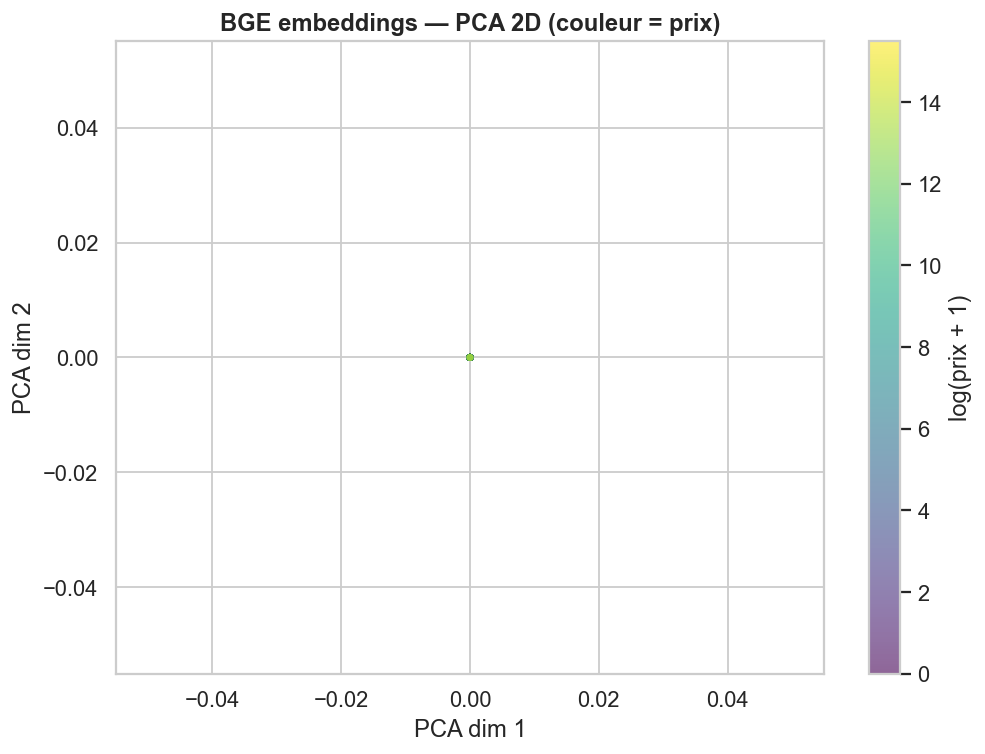

In [67]:
from sklearn.decomposition import PCA

N_COMPONENTS = CFG['embeddings']['n_components']  # 32

def compute_bge_pca(df_subset, n_components=N_COMPONENTS):
    if not BGE_AVAILABLE: return np.zeros((len(df_subset), n_components)), None
    texts = (
        df_subset['titre'].fillna('') + ' ' + df_subset['description'].fillna('')
    ).tolist()
    embs = bge_model.encode(texts, batch_size=64, show_progress_bar=True,
                             normalize_embeddings=True)
    pca = PCA(n_components=min(n_components, len(texts) - 1), random_state=RANDOM_SEED)
    reduced = pca.fit_transform(embs)
    explained = pca.explained_variance_ratio_.sum()
    print(f'  PCA {n_components}D — variance expliquee : {explained*100:.1f} %')
    return reduced, pca

BGE_DEMO_N = 200
df_bge = df.dropna(subset=['description']).sample(min(BGE_DEMO_N, len(df)), random_state=RANDOM_SEED)
embs_pca, pca_model = compute_bge_pca(df_bge)
print(f'BGE PCA shape : {embs_pca.shape}')

# Visualisation PCA 2D
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embs_pca[:, 0], embs_pca[:, 1],
                c=np.log1p(df_bge['prix'].fillna(0)), cmap='viridis',
                alpha=0.6, s=15, edgecolors='none')
plt.colorbar(sc, label='log(prix + 1)')
ax.set_title('BGE embeddings — PCA 2D (couleur = prix)', fontweight='bold')
ax.set_xlabel('PCA dim 1'); ax.set_ylabel('PCA dim 2')
plt.tight_layout(); plt.show()


---
## Export — Save NLP / Vision / BGE features as CSV

These CSVs are used by `Price_predict.ipynb` to enrich the Gold+ feature set.

In [68]:
# Build bge_df as a named DataFrame (indexed like df_bge)
if BGE_AVAILABLE and embs_pca is not None and len(embs_pca) > 0:
    bge_df = pd.DataFrame(
        {f'bge_pca_{i}': embs_pca[:, i] for i in range(embs_pca.shape[1])},
        index=df_bge.index
    )
    print(f'bge_df shape: {bge_df.shape}')
else:
    bge_df = pd.DataFrame()
    print("BGE not available — bge_df is empty.")

BGE not available — bge_df is empty.


In [69]:
# Export feature CSVs for use in Price_predict.ipynb
EXPORT_DIR = Path(r'C:\EstateMind\datasets')  # <-- adjust path if needed
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if len(nlp_flat) > 0:
    nlp_flat.to_csv(EXPORT_DIR / 'nlp_features.csv')
    print(f'nlp_features.csv saved — {nlp_flat.shape[0]:,} rows x {nlp_flat.shape[1]} cols')
else:
    print("nlp_flat is empty — skipping.")

if len(vis_df) > 0:
    vis_df.to_csv(EXPORT_DIR / 'vision_features.csv')
    print(f'vision_features.csv saved — {vis_df.shape[0]:,} rows x {vis_df.shape[1]} cols')
else:
    print("vis_df is empty — skipping.")

if len(bge_df) > 0:
    bge_df.to_csv(EXPORT_DIR / 'bge_pca_features.csv')
    print(f'bge_pca_features.csv saved — {bge_df.shape[0]:,} rows x {bge_df.shape[1]} cols')
else:
    print("bge_df is empty — skipping.")

print("\nDone. Run Price_predict.ipynb next.")

nlp_features.csv saved — 100 rows x 30 cols
vision_features.csv saved — 80,769 rows x 13 cols
bge_df is empty — skipping.

Done. Run Price_predict.ipynb next.
